# ALS_LLRF_MTS test on LBL208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.


### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf

/home/xilinx/jupyter_notebooks/pynq_llrf


In [2]:
from mimo_mts import MimoMtsOverlay
import numpy as np
from mimo_mts.utils.plot import plot_complex_wfm

%load_ext autoreload
%autoreload 2

In [3]:
# # reset PL to remove any cached .hwh file
# from pynq import PL
# PL.reset()

In [4]:
ol = MimoMtsOverlay(config='ALS_LLRF_LBL208')

In [5]:
ol

< MimoMtsOverlay >:
{ 'bitfile_name': 'als_llrf_mts.bit',
  'board': 'LBL208',
  'clk104_tcs': { 'lmk_tcs': 'designs/CLK104/DIST_MTS_LMK04828_5MHz_SYSREF.tcs',
                  'lmxadc_tcs': 'designs/CLK104/LMX2594_4000MHz.tcs',
                  'lmxdac_tcs': 'designs/CLK104/LMX2594_4000MHz.tcs'},
  'si570_freq_mhz': 156.1375}
RFDC MTS Latency Report:
DAC Tile 0 Latency: 128, Offset: 8
DAC Tile 1 Latency: 128, Offset: 8
DAC Tile 2 Latency: 128, Offset: 8
DAC Tile 3 Latency: 128, Offset: 8
ADC Tile 0 Latency:  96, Offset: 8
ADC Tile 1 Latency:  96, Offset: 8
ADC Tile 2 Latency:  96, Offset: 8
ADC Tile 3 Latency:  96, Offset: 8

In [6]:
ol.clk104

< CLK104Config >:
  === LMK04828: ===
part            :    LMK04828B
SYSREF_FREQ     :        4.996 MHz
OSCout_FREQ     :      160.009 MHz
CLKin0_FREQ     :      499.640 MHz
CLKin1_FREQ     :      499.640 MHz
CLKin2_FREQ     :       76.800 MHz
CLKout0_FREQ    :      499.640 MHz
CLKout1_FREQ    :        4.996 MHz
CLKout2_FREQ    :      499.640 MHz
CLKout3_FREQ    :        4.996 MHz
CLKout4_FREQ    :      499.640 MHz
CLKout5_FREQ    :        4.996 MHz
CLKout6_FREQ    :      499.640 MHz
CLKout7_FREQ    :        4.996 MHz
CLKout8_FREQ    :      499.640 MHz
CLKout9_FREQ    :        4.996 MHz
CLKout10_FREQ   :      499.640 MHz
CLKout11_FREQ   :      499.640 MHz
CLKout12_FREQ   :      499.640 MHz
CLKout13_FREQ   :        4.996 MHz
CLKin_SEL_MODE  :       CLKin0
VCO_MUX         : CLKin1 (ext)
  === LMX2594 ADC: ===
part            :      LMX2594
Fosc_FREQ       :      499.640 MHz
FoutA_FREQ      :     3997.120 MHz
FoutB_FREQ      :     3997.120 MHz
Fpd_FREQ        :      249.820 MHz
Fvco_FREQ 

In [7]:
ol.evr.check_frequencies()

In [8]:
ol.evr

GT EVR GTY:      ['xilinx.com:module_ref:axil_evr:1.0']
Event count:     223
GTY ref freq:    156.1371 MHz
GTY RX freq:     124.9106 MHz
Timestamp valid: True
Timestamp:       2147483648
GTY status:      0x7
RX aligned:      True

# Configure trigger and DSP

In [9]:
fs = ol.board.adc_sampling_rate
start = 1180  # start of the signal, measured
print(f'RF loop back latency: {start/fs * 1e9} ns')

RF loop back latency: 295.0 ns


In [10]:
ol.rf_control.register_map.trig_period = 250e6
ol.rf_control.register_map.trig_sel = 1  # EVR trigger
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 4096
ol.rf_control.register_map.amp_loop_setpoint = 0

There is a 3GHz band-pass filter between dac0 and adc0 loopback, and a direct loopback on adc1.

* Set DAC baseband waveform as DC
* Set DAC Mixer frequency to 3GHz for up conversion
* Set ADC Mixer frequency to 0Hz to check RF waveform

In [11]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)
pulse_length_ns = 256  # short pulse
n_samples = int(pulse_length_ns / 2 / 1e9 * fs)  # interpolated by 2
dac_i[n_samples:] = 0
ol.write_dac_iq_buf(dac_i, dac_q)

In [12]:
ol.set_dac_mixer_dco(-3000, nyquist=2)
ol.set_adc_mixer_dco(0, phase=0)

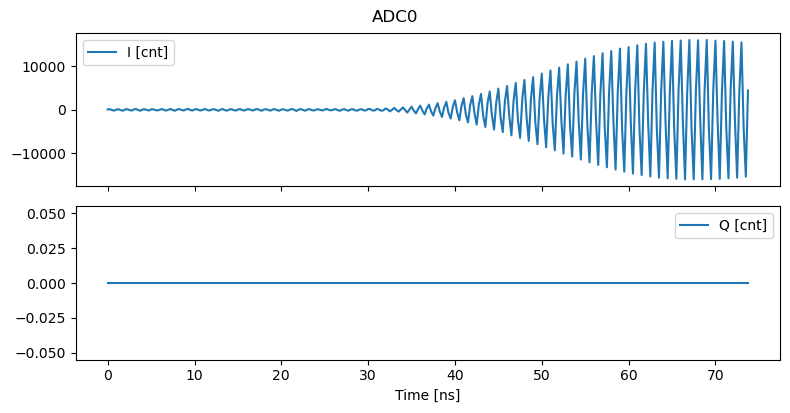

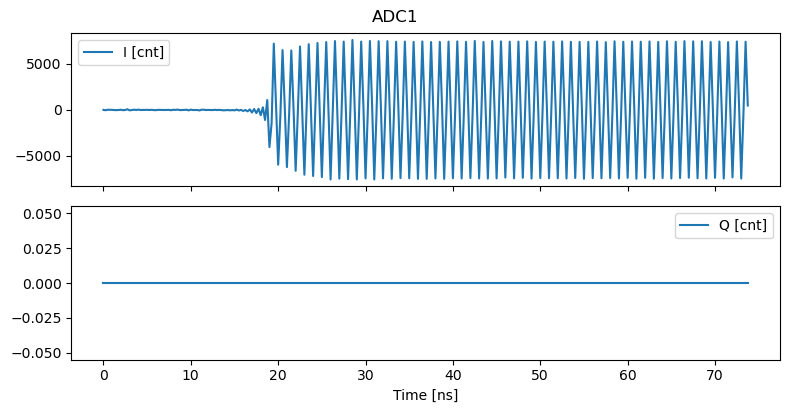

In [13]:
darray_i, darray_q = ol.capture_adc_iq_buf();
cdata = darray_i + 1j*darray_q
plot_complex_wfm(cdata[0, start-40:start+256], fs=fs, title='ADC0')
plot_complex_wfm(cdata[1, start-40:start+256], fs=fs, title='ADC1')

Set ADC Mixer frequency to 3GHz, check I/Q waveform after mixing.

In [14]:
ol.set_adc_mixer_dco(3000, nyquist=2, phase=0)

In [15]:
def get_dsp_waveform(ol=ol):
    """
    Get the DSP waveform from the ADC buffer.
    Average ADC data by 8 samples, as the same to the LLRF DSP,
    equivalent to a low pass filter to get base band signal.
    """
    darray_i, darray_q = ol.capture_adc_iq_buf();
    cdata = darray_i + 1j*darray_q
    return cdata.reshape(8, -1, 8).mean(axis=2)

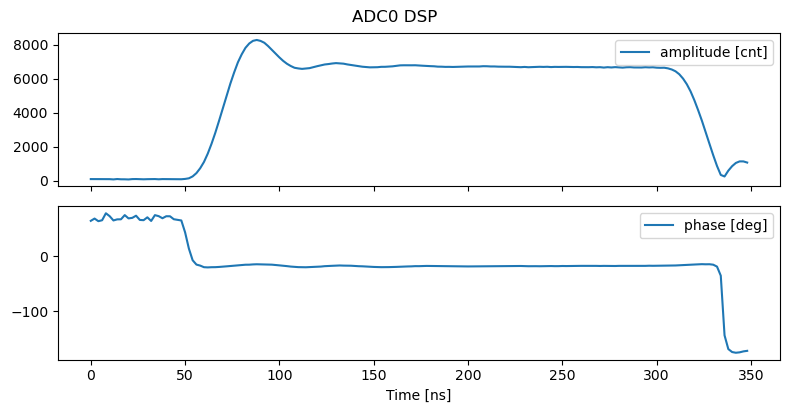

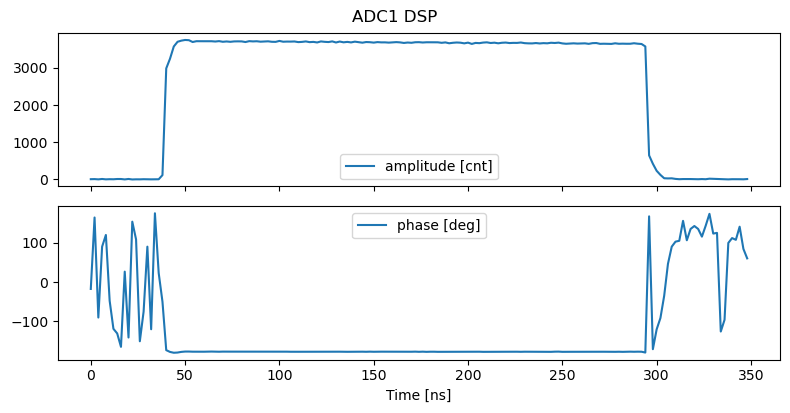

In [16]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm(cdata_dsp[0, (start-120)//8:(start+1280)//8], fs=fs/8, mode='ap', title='ADC0 DSP')
plot_complex_wfm(cdata_dsp[1, (start-120)//8:(start+1280)//8], fs=fs/8, mode='ap', title='ADC1 DSP')

# Disable dac buffer, use llrf amplitude setpoint for CW signal

In [17]:
ol.dac_player[:] = np.zeros(ol.dac_player.size, dtype=np.int16)

In [18]:
ol.rf_control.register_map.amp_loop_setpoint = 32767 / ol.rf_control.tx_gain
ol.rf_control.register_map.phs_loop_setpoint = 0

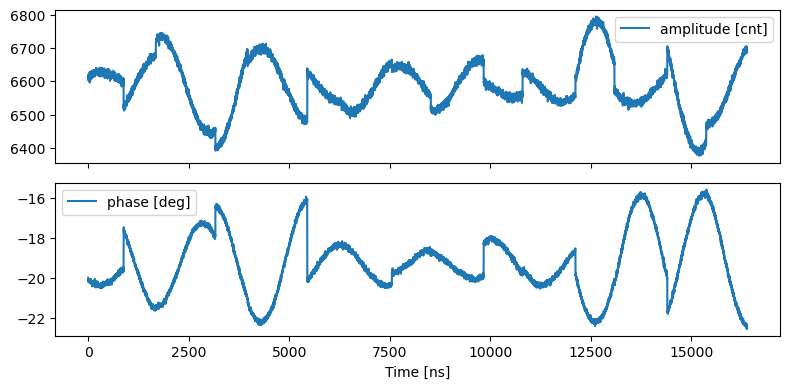

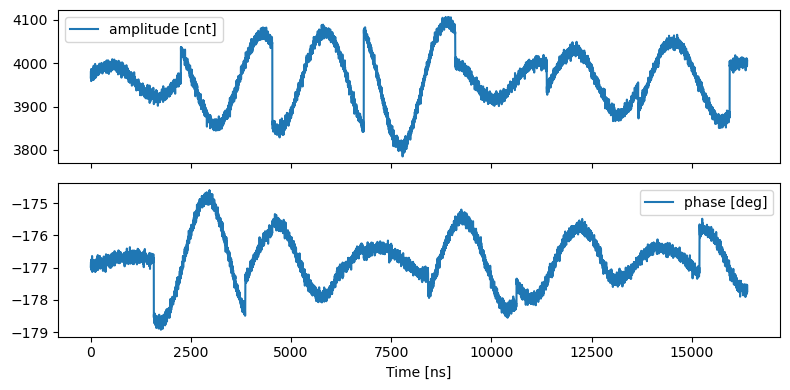

In [19]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm(cdata_dsp[0], fs=fs/8, mode='ap')
plot_complex_wfm(cdata_dsp[1], fs=fs/8, mode='ap')

# Check LLRF pulsing mode

In [20]:
ol.rf_control.register_map.dac_enable.pulse_enable=1

In [21]:
ol.rf_control.register_map.pulse_length=100

Expect 4 ns * 100 = 400 ns pulse length

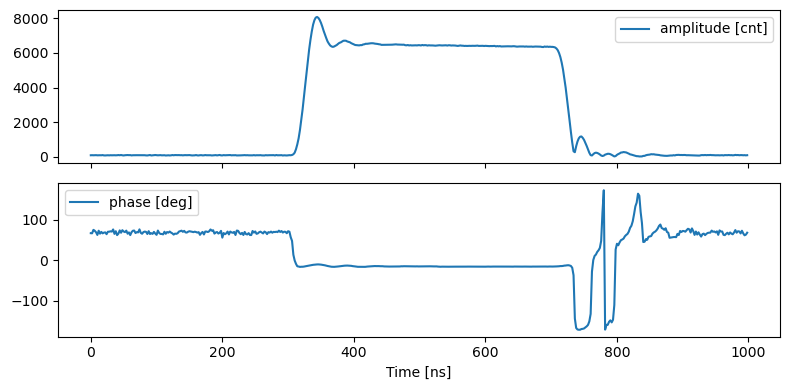

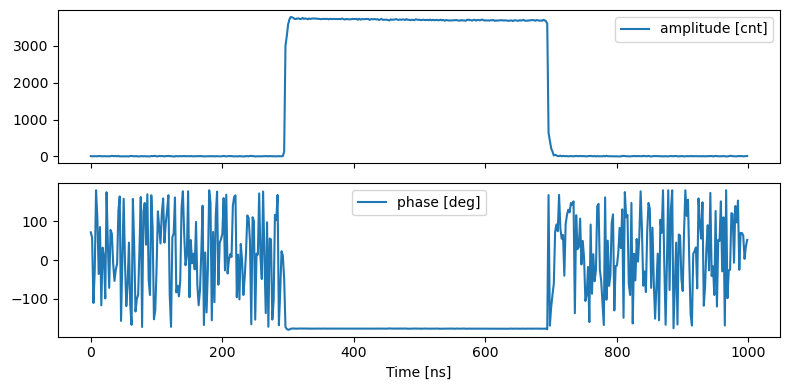

In [22]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm(cdata_dsp[0, :500], fs=fs/8, mode='ap')
plot_complex_wfm(cdata_dsp[1, :500], fs=fs/8, mode='ap')